In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np



##### k-neighbors regression

Il est possible de faire régression par cette méthode. L'étiquette  serait la valeur moyenne des étiquettes des k plus proches voisins.

X a un seul attribut

Les étiquettes  (y) sont des valeurs réeels

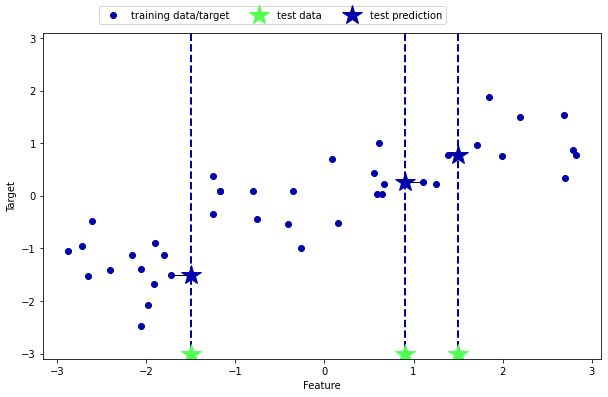

In [2]:
from IPython.display import Image

Image("knn_reg1.png")

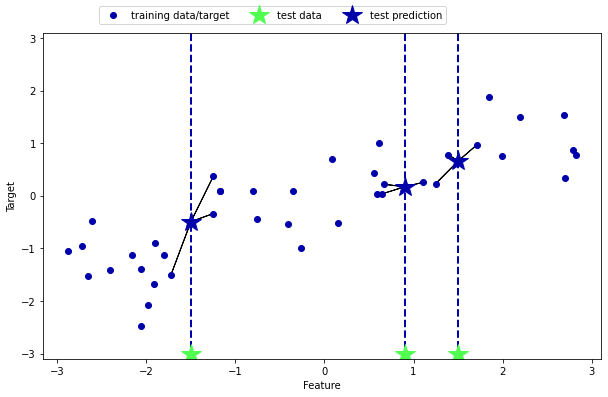

In [3]:
#Soient les plus proches voisins n1, n2, n3

#soient les étiquettes de ces 3 points: n1a, n2a, n3a

#on associe au point dont les 3 plus proches voisins sont n1, n2, n3

#na=1/3( n1a+n2a+n3a)

Image("knn_reg3.png")

In [4]:
def make_wave(n_samples=100):
    rnd = np.random.RandomState(42)
    x = rnd.uniform(-3, 3, size=n_samples)
    y_no_noise = (np.sin(4 * x) + x)
    y = (y_no_noise + rnd.normal(size=len(x))) / 2
    return x.reshape(-1, 1), y


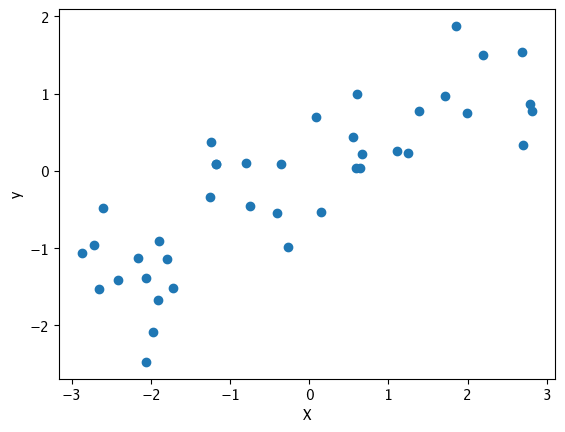

In [5]:
X,y=make_wave(40)
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()





In [6]:
#Définir les ensembles d'apprentissage et test

from sklearn.model_selection import train_test_split

# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True)






In [7]:
from sklearn.neighbors import KNeighborsRegressor

# Définir le modèle
reg3 = KNeighborsRegressor(n_neighbors=3)

# Faire apprentissage
reg3.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [8]:
#Estimer l'étiquette de Xnew= -1.3
reg3.predict([[-1.3]])

array([-0.3487268])

In [9]:
print(X_test)

yk_3= reg3.predict(X_test)
print("Test set predictions:\n", yk_3)

[[-1.25262516]
 [-1.17454654]
 [-1.89957294]
 [-1.80195731]
 [-2.06388816]
 [ 1.99465584]
 [-2.41396732]
 [ 0.08540663]
 [-0.35908504]
 [-2.65149833]]
Test set predictions:
 [ 0.18836016  0.18836016 -2.07693788 -1.75751624 -1.89415682  1.44592491
 -0.85177421 -0.35898987 -0.65851598 -0.8301424 ]


In [10]:
print("Test set {} ".format(reg3.score(X_test, y_test)))

Test set 0.2437997515208531 


In [11]:
from sklearn.metrics import mean_squared_error

print("MSE  {} ".format(mean_squared_error(y_test,reg3.predict(X_test))))

from sklearn.metrics import r2_score 

print("r2score  {} ".format(r2_score(y_test,reg3.predict(X_test))))

MSE  0.5274222024714348 
r2score  0.2437997515208531 


<function matplotlib.pyplot.show(close=None, block=None)>

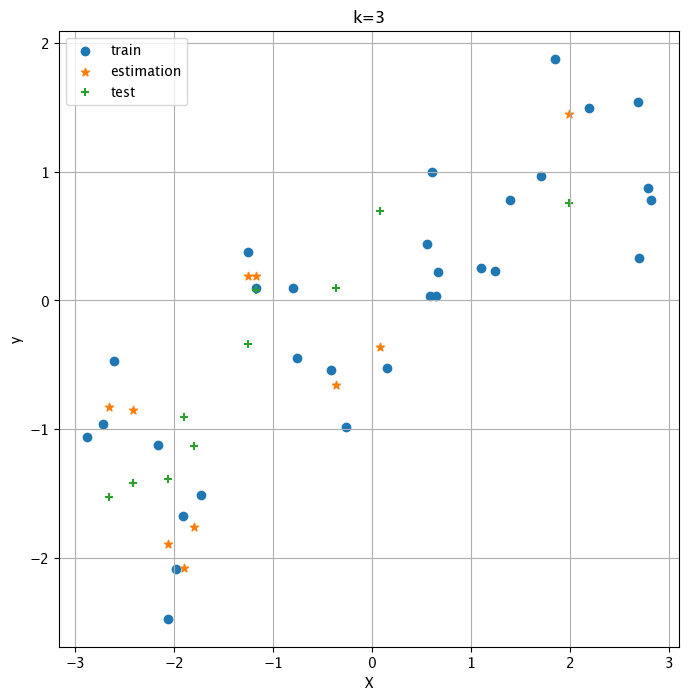

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(X_train, y_train)
plt.scatter(X_test, yk_3 ,  marker= '*')
plt.scatter(X_test, y_test ,  marker= '+')
plt.xlabel("X")
plt.ylabel("y")
plt.legend(["train", "estimation","test"])
plt.title("k=3")
plt.grid()
plt.show

In [13]:
from sklearn.neighbors import KNeighborsRegressor

# Définir le modèle
reg1 = KNeighborsRegressor(n_neighbors=1)

# Faire apprentissage
reg1.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=1)

In [14]:
#Estimer l'étiquette de Xnew= -1.3
reg1.predict([[-1.3]])

array([0.37299129])

In [15]:
yk_1= reg1.predict(X_test)

In [16]:
print("Test set score {} ".format(reg1.score(X_test, y_test)))

print("MSE  {} ".format(mean_squared_error(y_test,reg1.predict(X_test))))


print("r2score  {} ".format(r2_score(y_test,reg1.predict(X_test))))

Test set score -0.08654700725736886 
MSE  0.7578270660568693 
r2score  -0.08654700725736886 


<function matplotlib.pyplot.show(close=None, block=None)>

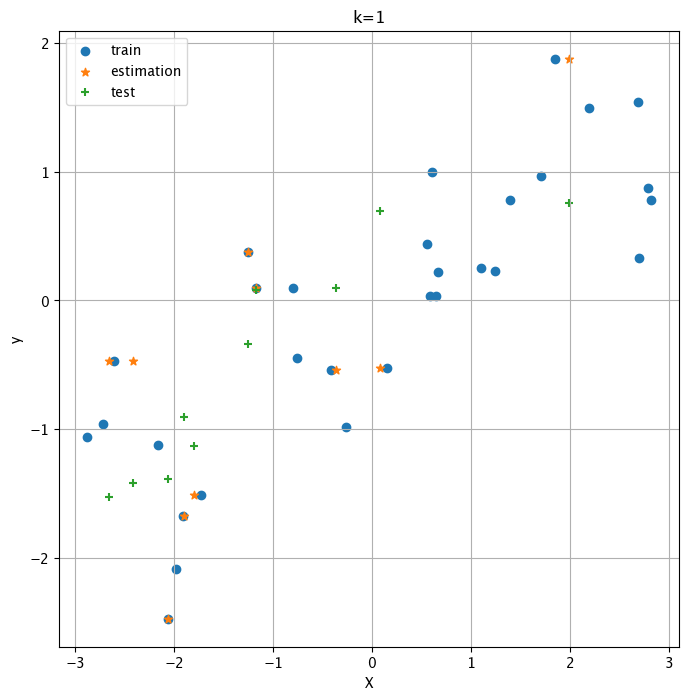

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(X_train, y_train)
plt.scatter(X_test, yk_1 ,  marker= '*')
plt.scatter(X_test, y_test ,  marker= '+')
plt.xlabel("X")
plt.ylabel("y")
plt.legend(["train", "estimation","test"])
plt.title("k=1")
plt.grid()
plt.show

Text(0.5, 1.0, 'k=1')

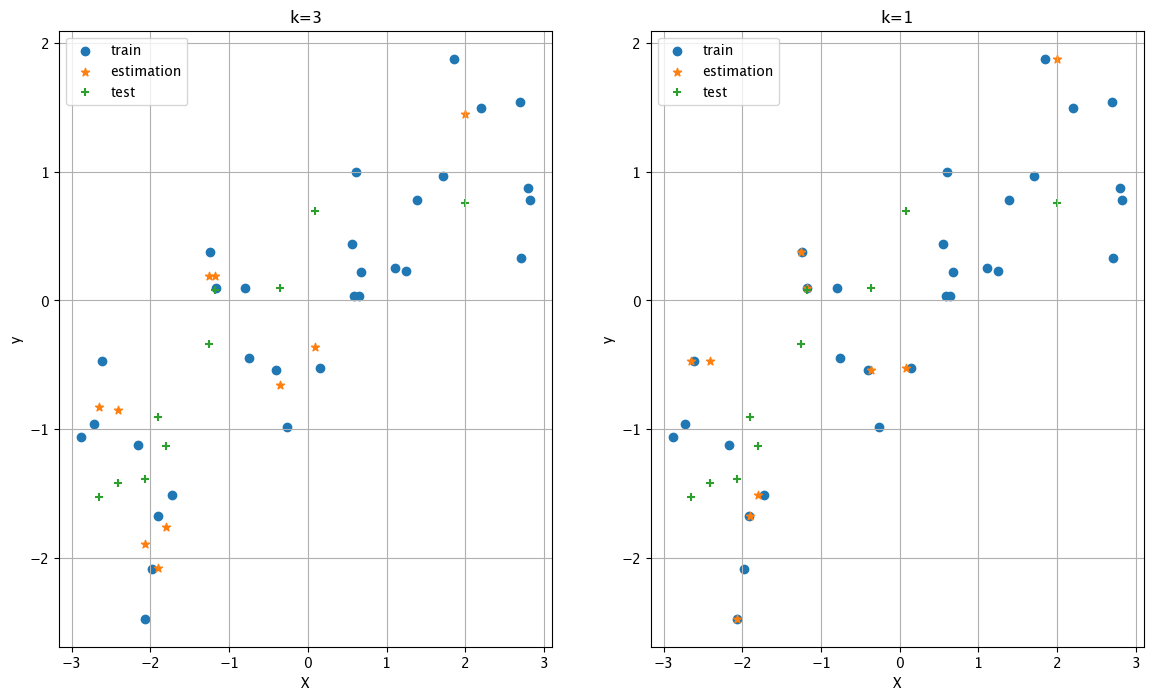

In [18]:
f,(f1, f2) = plt.subplots(1, 2, figsize=(14,8))

f1.scatter(X_train, y_train)
f1.scatter(X_test, yk_3 ,  marker= '*')
f1.scatter(X_test, y_test ,  marker= '+')
f1.set_xlabel("X")
f1.set_ylabel("y")
f1.legend(["train", "estimation","test"])
f1.grid()
f1.set_title("k=3")

f2.scatter(X_train, y_train)
f2.scatter(X_test, yk_1 ,  marker= '*')
f2.scatter(X_test, y_test ,  marker= '+')
f2.set_xlabel("X")
f2.set_ylabel("y")
f2.legend(["train", "estimation","test"])
f2.grid()
f2.set_title("k=1")


In [19]:
# Définir le modèle
reg5 = KNeighborsRegressor(n_neighbors=5)

# Faire apprentissage
reg5.fit(X_train, y_train)

yk_5= reg5.predict(X_test)

In [20]:
print("Test set score {} ".format(reg5.score(X_test, y_test)))

print("MSE  {} ".format(mean_squared_error(y_test,reg5.predict(X_test))))


print("r2score  {} ".format(r2_score(y_test,reg5.predict(X_test))))

Test set score 0.5358006680514152 
MSE  0.32376217084626185 
r2score  0.5358006680514152 


Text(0.5, 1.0, 'k=5')

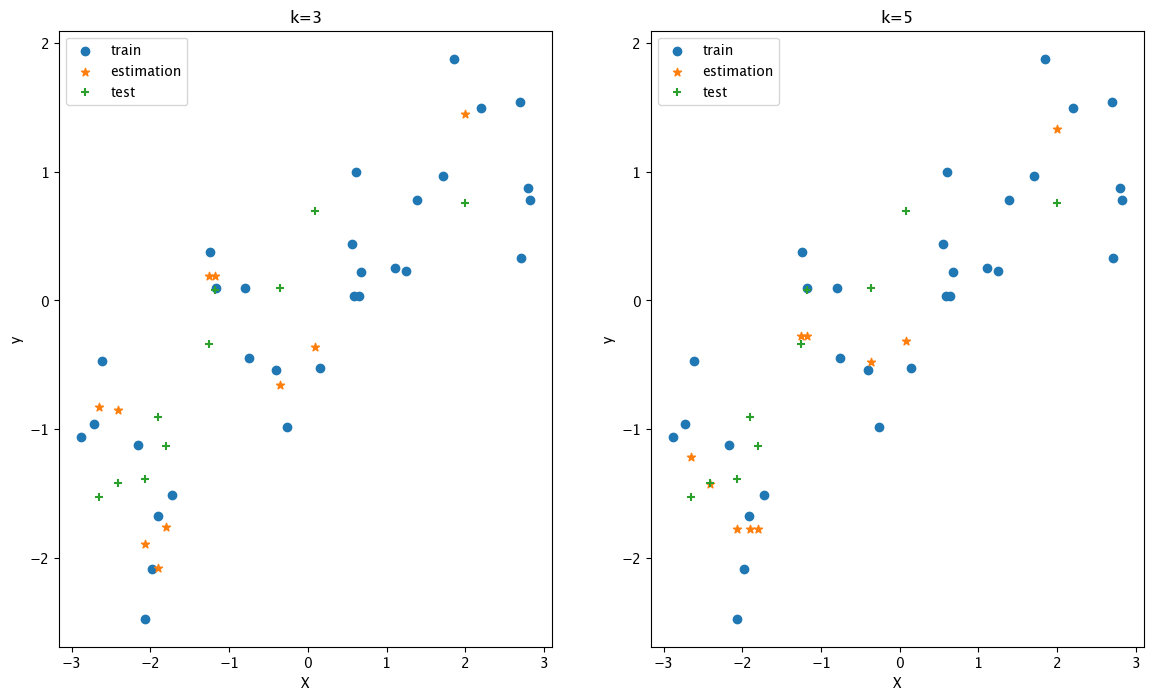

In [21]:
f,(f1, f2) = plt.subplots(1, 2, figsize=(14,8))

f1.scatter(X_train, y_train)
f1.scatter(X_test, yk_3 ,  marker= '*')
f1.scatter(X_test, y_test ,  marker= '+')
f1.set_xlabel("X")
f1.set_ylabel("y")
f1.legend(["train", "estimation","test"])
f1.grid()
f1.set_title("k=3")

f2.scatter(X_train, y_train)
f2.scatter(X_test, yk_5 ,  marker= '*')
f2.scatter(X_test, y_test ,  marker= '+')
f2.set_xlabel("X")
f2.set_ylabel("y")
f2.legend(["train", "estimation","test"])
f1.grid()
f2.set_title("k=5")


Quelle valeur de k donne la meilleur résultat?

In [22]:
reg2 = KNeighborsRegressor(n_neighbors=2)

# Faire apprentissage
reg2.fit(X_train, y_train)

yk_2= reg2.predict(X_test)
print("Test set score {} ".format(reg2.score(X_test, y_test)))

print("MSE  {} ".format(mean_squared_error(y_test,reg2.predict(X_test))))


print("r2score  {} ".format(r2_score(y_test,reg2.predict(X_test))))

#########################################

reg4 = KNeighborsRegressor(n_neighbors=4)

# Faire apprentissage
reg4.fit(X_train, y_train)

yk_4= reg4.predict(X_test)
print("Test set score {} ".format(reg4.score(X_test, y_test)))

print("MSE  {} ".format(mean_squared_error(y_test,reg4.predict(X_test))))


print("r2score  {} ".format(r2_score(y_test,reg4.predict(X_test))))

Test set score -0.012829172045567327 
MSE  0.7064115539791757 
r2score  -0.012829172045567327 
Test set score 0.40559704188871903 
MSE  0.4145744701262591 
r2score  0.40559704188871903 


[1, 2, 3, 4, 5]
[0.7578270660568693, 0.7064115539791757, 0.5274222024714348, 0.4145744701262591, 0.32376217084626185]


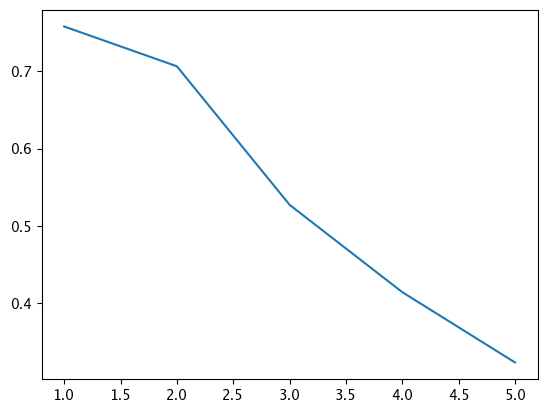

In [23]:
x= [1,2,3,4,5]
y=[mean_squared_error(y_test,reg1.predict(X_test)), mean_squared_error(y_test,reg2.predict(X_test)),
   mean_squared_error(y_test,reg3.predict(X_test)), mean_squared_error(y_test,reg4.predict(X_test)),
   mean_squared_error(y_test,reg5.predict(X_test))]
print (x)
print(y)
plt.plot(x, y)

 Répétez  l'expérience en prénant random_state=42. Avez-vous trouvé les mêmes résultats?